# NB5 — Causal Analysis: Activation Patching & K-Composition

NB4 proved the induction heads are **necessary** (ablation) and measured their **direct** effect on
the logits (DLA). This notebook makes the causal story sharper with two more techniques:

1. **Activation patching** — the headline interpretability tool. Instead of *destroying* an
   activation (ablation), we **transplant** a clean activation into a corrupted run and watch how
   much the behaviour *recovers*. This *localizes* exactly which component carries the signal.
2. **K-composition score** — a **weight-level** measurement showing the prev-token head (L4H11)
   feeds the induction heads through their *keys*, closing the loop the NB4 ablation only implied.

By the end you'll have found the induction heads **three independent ways** (attention score in NB3,
DLA in NB4, patching here) — and shown *why* the circuit is wired the way it is.

## Activation patching, conceptually

Ablation replaces an activation with something *uninformative* (zero/mean) and asks "what breaks?"
Activation patching is more surgical. You run the model **twice**:

- a **clean** run, where the behaviour works, and
- a **corrupted** run, where it's broken,

then you take *one* activation from the clean run and **splice it into** the corrupted run, leaving
everything else corrupted. If that single patched activation makes the corrupted run behave like the
clean one, then *that activation carried the information*. This "corrupt everything, restore one
piece" direction is called **denoising**.

**Designing clean/corrupted for induction.** We want two runs that differ *only* in whether induction
can fire, while keeping the same second-copy tokens (so the prediction target is identical):

```
clean   = [BOS,   seq  , seq]     induction works: the second copy repeats the first
corrupt = [BOS, seq_bad, seq]     first copy is DIFFERENT random tokens -> the induction lookup
                                  finds no matching previous occurrence -> induction fails
```

Both share the **same second copy**, so the correct next tokens are identical — only the *mechanism*
is broken in `corrupt`. That's the clean experimental control patching needs.

## 0. Setup

In [1]:
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer, utils

torch.set_grad_enabled(False)
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained("gpt2", device=device)
nL, nH = model.cfg.n_layers, model.cfg.n_heads
print("model on", device)

C:\Users\alexa\AppData\Local\Temp\ipykernel_10480\1690101088.py:3: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens import HookedTransformer, utils


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
model on cuda


## 1. Clean, corrupted, and the metric

We build the two inputs and a **metric** that scores induction: the mean log-probability of the
correct next token over the second-copy positions (same slice as NB4). High (near 0) = induction
working; very negative = broken.

The gap between the clean and corrupted metric is the "room to recover" — patching experiments are
measured as the *fraction of this gap* that a patched activation restores.

In [11]:
seq_len, batch = 50, 5
bos = torch.full((batch, 1), model.tokenizer.bos_token_id, dtype=torch.long)
seq      = torch.randint(0, model.cfg.d_vocab, (batch, seq_len))
seq_bad  = torch.randint(0, model.cfg.d_vocab, (batch, seq_len))   # a DIFFERENT random first copy

clean   = torch.cat([bos, seq,     seq], dim=1).to(device)         # induction works
corrupt = torch.cat([bos, seq_bad, seq], dim=1).to(device)         # induction broken, same 2nd copy

pos_slice = slice(seq_len, -1)                 # second-copy prediction positions
correct = clean[:, seq_len + 1:]               # targets — identical for clean & corrupt by construction

def induction_metric(logits):
    """Mean log-prob of the correct next token over second-copy positions."""
    log_probs = logits.log_softmax(-1)[:, pos_slice]           # [batch, npos, vocab]
    return log_probs.gather(-1, correct[:, :, None])[..., 0].mean().item()

clean_metric   = induction_metric(model(clean))
corrupt_metric = induction_metric(model(corrupt))
print(f"clean metric   : {clean_metric:.3f}   (induction works)")
print(f"corrupt metric : {corrupt_metric:.3f}   (induction broken)")
print(f"gap to recover : {clean_metric - corrupt_metric:.3f}")

clean metric   : -0.626   (induction works)
corrupt metric : -12.386   (induction broken)
gap to recover : 11.760


## 2. The patching mechanism

First cache **all** the clean activations — those are the values we'll transplant. Then we run the
**corrupted** input with a hook that, at one chosen head, overwrites the corrupted `z` with the
**clean** `z` for that head. Everything else stays corrupted.

This is an *editing* hook (like NB4's ablation), but instead of zeroing, it copies in a clean value.
`hook.name` gives the current hook point's full name (e.g. `blocks.7.attn.hook_z`), which we use to
pull the matching tensor straight out of `clean_cache`.

Let's patch a single head — **L7H2**, our top DLA/patching head — and measure the recovery.

In [12]:
_, clean_cache = model.run_with_cache(clean)      # the clean activations we'll transplant

def patch_head_z(head):
    """Return a hook that overwrites `head`'s z with the clean run's z."""
    def hook(z, hook):                            # z: [batch, pos, head, d_head] (from the corrupt run)
        z[:, :, head, :] = clean_cache[hook.name][:, :, head, :]   # splice in clean values
        return z
    return hook

L, H = 7, 2
patched_logits = model.run_with_hooks(
    corrupt,
    fwd_hooks=[(utils.get_act_name("z", L), patch_head_z(H))],
)
m = induction_metric(patched_logits)
recovery = (m - corrupt_metric) / (clean_metric - corrupt_metric)
print(f"patch L{L}H{H}: metric {m:.3f}  ->  recovers {recovery:.1%} of the clean-corrupt gap")

patch L7H2: metric -10.876  ->  recovers 12.8% of the clean-corrupt gap


## Practice — patch every head and localize the circuit

Now do it for **all 144 heads** and make a recovery heatmap. This is activation patching's payoff: a
map of *which heads carry the induction signal*, built purely from causal interventions.

**Your task:**
1. Loop over every `(L, H)`. For each, run `corrupt` with `patch_head_z(H)` attached at layer `L`'s
   `z` hook, and store the **recovery fraction** `(metric - corrupt_metric) / (clean_metric - corrupt_metric)`
   into `recovery[L, H]`.
2. Plot `recovery` as a layers×heads heatmap (reuse the `plt.imshow` recipe from NB3).
3. Print the top-6 heads. You should see the induction heads (L7H2, L6H9, L5H1, L7H10, …) light up —
   the *same* heads NB3 and NB4 found, now confirmed by a third, independent method.

Hints: single-head recovery is small (no one head does it all), so use a sensitive colormap. The
hook name for layer `L` is `utils.get_act_name("z", L)`.

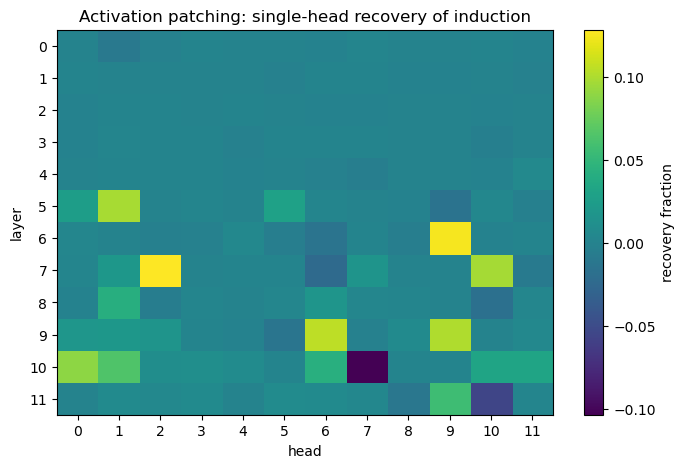

Top induction heads:
  L7H2: 0.128
  L6H9: 0.125
  L9H6: 0.105
  L9H9: 0.101
  L5H1: 0.098


In [16]:
recovery = torch.zeros(nL, nH)

for L in range(nL):
     for H in range(nH):
        logits = model.run_with_hooks(corrupt, fwd_hooks=[(utils.get_act_name("z", L), patch_head_z(H))])
        recovery[L, H] = (induction_metric(logits) - corrupt_metric) / (clean_metric - corrupt_metric)

# plot recovery as a heatmap, and print the top-6 heads
plt.figure(figsize=(8, 5))
plt.imshow(recovery.numpy(), aspect="auto", cmap="viridis", origin="upper")
plt.colorbar(label="recovery fraction"); plt.xlabel("head"); plt.ylabel("layer")
plt.title("Activation patching: single-head recovery of induction")
plt.xticks(range(nH)); plt.yticks(range(nL)); plt.show()

flat = recovery.flatten()
print("Top induction heads:")
for i in flat.topk(5).indices:
    print(f"  L{int(i)//nH}H{int(i)%nH}: {flat[i]:.3f}")

<details>
<summary>Reference solution (open after you've tried)</summary>

```python
recovery = torch.zeros(nL, nH)
for L in range(nL):
    for H in range(nH):
        logits = model.run_with_hooks(corrupt, fwd_hooks=[(utils.get_act_name("z", L), patch_head_z(H))])
        recovery[L, H] = (induction_metric(logits) - corrupt_metric) / (clean_metric - corrupt_metric)

plt.figure(figsize=(8, 5))
plt.imshow(recovery.numpy(), aspect="auto", cmap="viridis", origin="upper")
plt.colorbar(label="recovery fraction"); plt.xlabel("head"); plt.ylabel("layer")
plt.title("Activation patching: single-head recovery of induction")
plt.xticks(range(nH)); plt.yticks(range(nL)); plt.show()

flat = recovery.flatten()
for i in flat.topk(6).indices:
    print(f"L{int(i)//nH}H{int(i)%nH}: {flat[i]:.3f}")
```

Expected top heads: L7H2, L6H9, L5H1, L7H10 (induction) plus a couple of later output heads (L9H*).

</details>

## 3. K-composition score — proving the wiring at the weights

Patching and ablation are *behavioural* — they act on activations for specific inputs. The
K-composition score is different: it's computed **from the weights alone**, no data, and measures how
much one head's output feeds another head's **keys**.

Recall the mechanism (NB4): the prev-token head writes a "my predecessor was X" tag into the residual
stream, and the induction head reads that tag through its **keys** (the K in QK). If that's real, the
induction head's key-map should have large overlap with the prev-token head's output-map.

Using the full per-head matrices `W_OV = W_V @ W_O` (what a head writes) and `W_QK = W_Q @ W_Kᵀ` (a
head's query-key map), the **K-composition score** for source `A` → destination `B` is

```
score = || W_QK[B] @ W_OV[A]ᵀ ||_F  /  ( || W_QK[B] ||_F · || W_OV[A] ||_F )
```

a normalized (Frobenius-norm) measure in `[0, 1]` of how much B's keys read A's output. Let's compute
it for **L4H11 → each induction head** and compare to the typical score.

In [17]:
# Full per-head weight matrices: [n_layers, n_heads, d_model, d_model]
W_OV = model.W_V @ model.W_O                       # what each head writes to the residual stream
W_QK = model.W_Q @ model.W_K.transpose(-1, -2)     # each head's query-key map

def k_composition(src, dst):
    """K-comp score for src=(L,H) feeding dst=(L,H)'s keys, from weights alone."""
    A = W_OV[src]          # [d_model, d_model]
    B = W_QK[dst]          # [d_model, d_model]
    return ((B @ A.transpose(-1, -2)).norm() / (A.norm() * B.norm())).item()

prev_token_head = (4, 11)
induction_heads = [(5, 5), (5, 1), (6, 9), (7, 10), (7, 2)]

print("K-composition score  L4H11 -> induction head:")
for dst in induction_heads:
    print(f"  L4H11 -> L{dst[0]}H{dst[1]}: {k_composition(prev_token_head, dst):.4f}")

# Baseline: L4H11's mean K-comp to ALL heads in layers 5-7.
all_scores = [k_composition(prev_token_head, (L, H)) for L in range(5, 8) for H in range(nH)]
print(f"\nmean L4H11 -> (any head in layers 5-7): {sum(all_scores)/len(all_scores):.4f}")
print("-> the induction heads score ~2x the baseline: L4H11 composes with them specifically.")

K-composition score  L4H11 -> induction head:
  L4H11 -> L5H5: 0.0972
  L4H11 -> L5H1: 0.1023
  L4H11 -> L6H9: 0.1035
  L4H11 -> L7H10: 0.0896
  L4H11 -> L7H2: 0.0872

mean L4H11 -> (any head in layers 5-7): 0.0481
-> the induction heads score ~2x the baseline: L4H11 composes with them specifically.


## The circuit, now proven three ways

| Question | Technique | Notebook | Answer |
|----------|-----------|----------|--------|
| Which heads attend like induction heads? | induction score (attention) | NB3 | L5H5, L5H1, L6H9, L7H10, L7H2 |
| Which heads write the answer to the logits? | direct logit attribution | NB4 | L7H2, L7H10, L6H9 (+ L9 output heads) |
| Which heads are **necessary**? | ablation | NB4 | ablating them: loss 0.5 → 5+ |
| Which heads **causally carry** the signal? | activation patching | **NB5** | L7H2, L6H9, L5H1, L7H10 recover induction |
| **Why** does the prev-token head matter? | K-composition score | **NB5** | L4H11 composes with the induction heads' keys, ~2x baseline |

Five different lenses, one consistent circuit: **L4H11 (prev-token) → {L5/L6/L7 induction heads} →
logits**, wired through K-composition. That agreement across independent methods is exactly what a
solid mechanistic-interpretability result looks like.

---
**Done?** Finish the patching-loop practice cell and you've localized the circuit a third way.

Where to go next, if you want to keep pushing:
- **Path patching** — patch a *specific* path (e.g. L4H11's output *into L6H9's keys only*), the
  gold-standard test that isolates one edge of the circuit rather than a whole head.
- **Q- and V-composition scores** — repeat the weight analysis for the query and value paths; you
  should find K-composition dominates for induction.
- **A new behaviour** — rerun this whole workflow (find heads → ablate → DLA → patch → composition)
  on the **IOI** circuit to practice on a richer, multi-head task.